# House Price Prediction using Multi-Linear Regression

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Loading cleaned dataset
df = pd.read_csv('Price_Conversion_cleaned_and_Proper.csv')

# Define Features (X) and Target (y)
X = df.drop(['price_lakh', 'log_price'], axis=1)
y = df['log_price']

# Training and Testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and Train the Model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Predictions
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

# Metrics Calculation
mse = mean_squared_error(y_test, y_test_pred)
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

print(f"Multi-Linear Regression Metrics")
print(f"Mean Squared Error: {mse:.4f}")
print(f"R2 Score (Train): {r2_train:.4f}")
print(f"R2 Score (Test): {r2_test:.4f}")

# Converting log predictions back to actual house prices (Lakhs)
actual_prices = np.expm1(y_test)
predicted_prices = np.expm1(y_test_pred)

comparison_df = pd.DataFrame({'Actual Price (Lakhs)': actual_prices, 'Predicted Price (Lakhs)': predicted_prices})
print("\nSample Predicted House Prices")
print(comparison_df.head(10))

Multi-Linear Regression Metrics
Mean Squared Error: 0.0255
R2 Score (Train): 0.9458
R2 Score (Test): 0.9454

Sample Predicted House Prices
       Actual Price (Lakhs)  Predicted Price (Lakhs)
19893                 29.50                54.800646
36271                 59.00                54.563065
43781                100.00               103.555585
27999                 86.87                83.283023
21025                177.00               309.330186
6067                  24.05                38.190790
8440                  78.00                85.400322
31104                124.00               109.209613
4850                  78.90                70.996596
11708                 80.00                76.857090


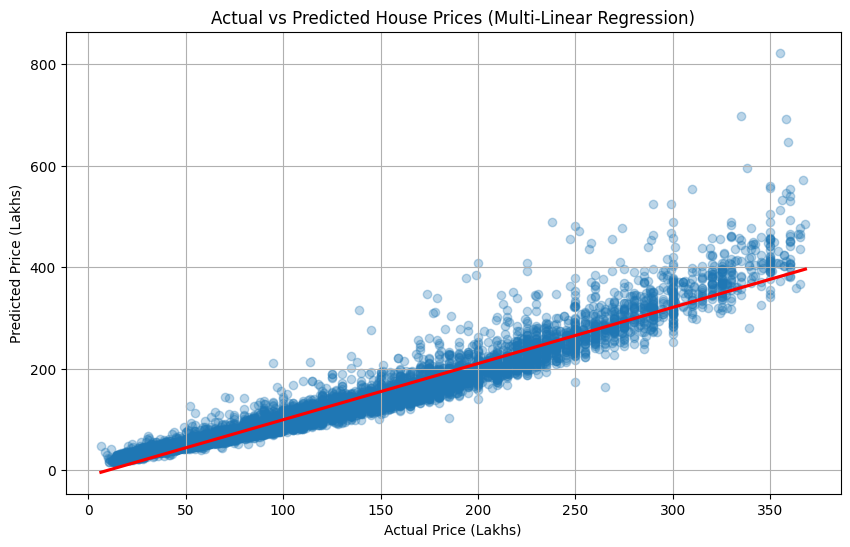

In [5]:
# Visualization: Actual vs Predicted Prices
plt.figure(figsize=(10, 6))
sns.regplot(x=actual_prices, y=predicted_prices, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.xlabel('Actual Price (Lakhs)')
plt.ylabel('Predicted Price (Lakhs)')
plt.title('Actual vs Predicted House Prices (Multi-Linear Regression)')
plt.grid(True)
plt.show()